# Numerical dispersion with energy-dependent diffuseness

This notebook compares two DOM views of the surface dispersive correction:

1. **Analytic / parametric DOM approximation**: apply the analytic Kramers-Kronig correction only to the depth, then evaluate the surface shape at the target energy.
2. **Full numerical dispersion**: evaluate the non-separable surface term `W(r, E)` on the quadrature nodes and use `DispersionSolver` to integrate it.

The two approaches agree at `r = R`, where the surface shape is unity and the energy dependence of the diffuseness drops out. Away from `r = R`, the difference shows the approximation made by the analytic DOM depth-only correction.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from jitr.optical_potentials import dom
from jitr.optical_potentials.dispersion import DispersionSolver

In [2]:
dense_segments = (
    (-1200.0, -200.0, 24),
    (-200.0, -50.0, 36),
    (-50.0, -15.0, 48),
    (-15.0, 15.0, 72),
    (15.0, 50.0, 48),
    (50.0, 200.0, 36),
    (200.0, 1200.0, 24),
)


def quartic_diffuseness(E, a_min=0.30, a_max=0.60, lambda_a=12.0):
    E2 = np.asarray(E, dtype=float) ** 2
    return a_min + (a_max - a_min) * E2**2 / (E2**2 + lambda_a**4)


def surface_shape(r, R, a):
    return 1.0 / np.cosh((r - R) / (2.0 * a)) ** 2


def surface_imaginary(r, E, Ws0, ws1, ws2, R, a_min, a_max, lambda_a):
    a_E = quartic_diffuseness(E, a_min=a_min, a_max=a_max, lambda_a=lambda_a)
    return dom.Ws_depth(E, Ws0, ws1, ws2) * surface_shape(r, R, a_E)


def parametric_surface_dispersion(r_grid, E, Ws0, ws1, ws2, R, a_min, a_max, lambda_a):
    a_E = quartic_diffuseness(E, a_min=a_min, a_max=a_max, lambda_a=lambda_a)
    return dom.delta_Vs_analytic(E, Ws0, ws1, ws2) * surface_shape(r_grid, R, a_E)


def numerical_surface_dispersion(
    r_grid, E, Ws0, ws1, ws2, R, a_min, a_max, lambda_a, segments=dense_segments
):
    solver = DispersionSolver(r_grid, E=E, segments=segments)
    W_grid = np.array(
        [
            [
                surface_imaginary(r, x, Ws0, ws1, ws2, R, a_min, a_max, lambda_a)
                for x in solver.x_quad
            ]
            for r in r_grid
        ]
    )
    W_at_E = np.array(
        [
            surface_imaginary(r, E, Ws0, ws1, ws2, R, a_min, a_max, lambda_a)
            for r in r_grid
        ]
    )
    return solver(W_grid, W_at_E)

In [3]:
config = {
    "Ws0": 15.0,
    "ws1": 12.5,
    "ws2": 0.021,
    "R": 4.55,
    "a_min": 0.30,
    "a_max": 0.60,
    "lambda_a": 12.0,
}

probe_energies = np.array([4.0, 12.0, 24.0, 40.0])
r_grid = np.linspace(config["R"] - 1.4, config["R"] + 1.8, 60)

agreement_at_R = []
for E in probe_energies:
    param_R = parametric_surface_dispersion(np.array([config["R"]]), E, **config)[0]
    full_R = numerical_surface_dispersion(np.array([config["R"]]), E, **config)[0]
    agreement_at_R.append((E, param_R, full_R, full_R - param_R))

agreement_at_R

[(np.float64(4.0),
  np.float64(2.1177112085106016),
  np.float64(2.117711209091137),
  np.float64(5.805356195764944e-10)),
 (np.float64(12.0),
  np.float64(5.285500110825252),
  np.float64(5.285500111023508),
  np.float64(1.9825563413178315e-10)),
 (np.float64(24.0),
  np.float64(-0.24080629836458195),
  np.float64(-0.24080629826529118),
  np.float64(9.929077005033093e-11)),
 (np.float64(40.0),
  np.float64(-3.204462309490639),
  np.float64(-3.204462309431121),
  np.float64(5.951772408252509e-11))]

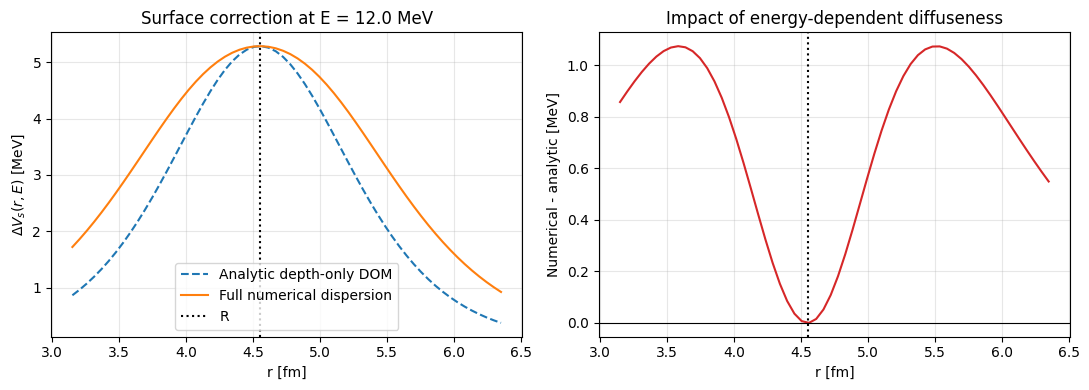

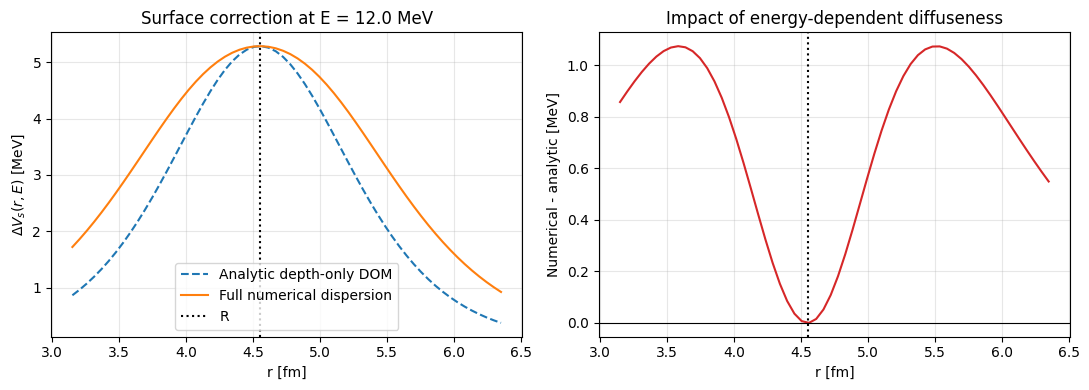

In [4]:
for _E, param_R, full_R, _diff in agreement_at_R:
    np.testing.assert_allclose(param_R, full_R, atol=2e-3, rtol=2e-3)

E_demo = 12.0
parametric = parametric_surface_dispersion(r_grid, E_demo, **config)
numerical = numerical_surface_dispersion(r_grid, E_demo, **config)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(r_grid, parametric, "--", label="Analytic depth-only DOM")
axes[0].plot(r_grid, numerical, "-", label="Full numerical dispersion")
axes[0].axvline(config["R"], color="black", linestyle=":", label="R")
axes[0].set_xlabel("r [fm]")
axes[0].set_ylabel(r"$\Delta V_s(r, E)$ [MeV]")
axes[0].set_title(f"Surface correction at E = {E_demo:.1f} MeV")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(r_grid, numerical - parametric, color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].axvline(config["R"], color="black", linestyle=":")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("Numerical - analytic [MeV]")
axes[1].set_title("Impact of energy-dependent diffuseness")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig

At `r = R`, the two approaches agree because the surface shape is exactly one. Away from `r = R`, the numerical solver captures the extra energy dependence from `a(E)`, while the analytic DOM approximation keeps only the depth-driven dispersive correction.